# Precision, Recall, and F1 for Sentiment Evaluation

Compare **resolved manual labels** (`Hand_Labeling_Task_Resolved.xlsx`) with **model predictions** (`full_dataset_with_predictions.csv`) on the overlapping `Review_ID` rows.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

sns.set_theme(style="whitegrid")

## 1. Data merging

Inner merge on `Review_ID` so each row is one of the 1,000 manually resolved labels aligned with model outputs.

In [ ]:
MANUAL_XLSX = "Hand_Labeling_Task_Resolved.xlsx"
PRED_CSV = "full_dataset_with_predictions.csv"

manual = pd.read_excel(MANUAL_XLSX, engine="openpyxl")
preds = pd.read_csv(PRED_CSV)

# Standardize manual column names
rename_map = {}
if "manual_subjectivity" not in manual.columns and "Subjectivity" in manual.columns:
    rename_map["Subjectivity"] = "manual_subjectivity"
if "manual_polarity" not in manual.columns and "Polarity" in manual.columns:
    rename_map["Polarity"] = "manual_polarity"
manual = manual.rename(columns=rename_map)

need = {"Review_ID", "manual_subjectivity", "manual_polarity"}
missing_m = need - set(manual.columns)
if missing_m:
    raise ValueError(f"Manual file missing columns {missing_m}. Found: {manual.columns.tolist()}")

need_p = {"Review_ID", "pred_subjectivity", "pred_polarity"}
missing_p = need_p - set(preds.columns)
if missing_p:
    raise ValueError(f"Predictions CSV missing {missing_p}. Found: {preds.columns.tolist()}")

merged = manual[["Review_ID", "manual_subjectivity", "manual_polarity"]].merge(
    preds[["Review_ID", "pred_subjectivity", "pred_polarity"]],
    on="Review_ID",
    how="inner",
    validate="one_to_one",
)

for col in ["manual_subjectivity", "manual_polarity", "pred_subjectivity", "pred_polarity"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

print(f"Merged rows: {len(merged)} (expected 1,000 for full overlap)")

# Rows used for scoring (drop incomplete label pairs)
merged_eval = merged.dropna(
    subset=["manual_subjectivity", "manual_polarity", "pred_subjectivity", "pred_polarity"]
)
if len(merged_eval) < len(merged):
    print(f"Warning: dropped {len(merged) - len(merged_eval)} rows with missing labels.")
merged.head(3)

Merged rows: 1000 (expected 1,000 for full overlap)


,Review_ID,manual_subjectivity,manual_polarity,pred_subjectivity,pred_polarity
0,RV06983,1,1,1,1
1,RV01598,1,1,1,1
2,RV04920,1,1,1,1


## 2. Subjectivity: metrics & confusion matrix

Binary task: `manual_subjectivity` vs `pred_subjectivity`.

SUBJECTIVITY — classification_report (full, copy for report)
              precision    recall  f1-score   support

      subj_0     0.0946    0.4667    0.1573        15
      subj_1     0.9914    0.9320    0.9608       985

    accuracy                         0.9250      1000
   macro avg     0.5430    0.6993    0.5590      1000
weighted avg     0.9779    0.9250    0.9487      1000

Subjectivity — Macro / Weighted / Micro F1
  Macro F1:    0.5590
  Weighted F1: 0.9487
  Micro F1:    0.9250


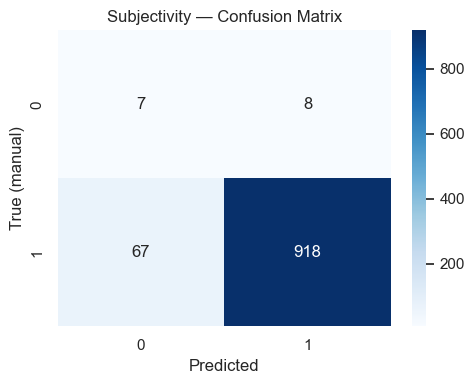

In [3]:
y_sub_true = merged_eval["manual_subjectivity"]
y_sub_pred = merged_eval["pred_subjectivity"]

sub_labels = sorted(set(y_sub_true.dropna().unique()) | set(y_sub_pred.dropna().unique()))
sub_names = [str(int(round(float(x)))) for x in sub_labels]

print("=" * 72)
print("SUBJECTIVITY — classification_report (full, copy for report)")
print("=" * 72)
print(
    classification_report(
        y_sub_true,
        y_sub_pred,
        labels=sub_labels,
        target_names=[f"subj_{n}" for n in sub_names],
        digits=4,
        zero_division=0,
    )
)

print("Subjectivity — Macro / Weighted / Micro F1")
print(
    f"  Macro F1:    {f1_score(y_sub_true, y_sub_pred, average='macro', labels=sub_labels, zero_division=0):.4f}"
)
print(
    f"  Weighted F1: {f1_score(y_sub_true, y_sub_pred, average='weighted', labels=sub_labels, zero_division=0):.4f}"
)
print(
    f"  Micro F1:    {f1_score(y_sub_true, y_sub_pred, average='micro', labels=sub_labels, zero_division=0):.4f}"
)

cm_sub = confusion_matrix(y_sub_true, y_sub_pred, labels=sub_labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_sub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sub_names,
    yticklabels=sub_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True (manual)")
ax.set_title("Subjectivity — Confusion Matrix")
plt.tight_layout()
plt.show()

## 3. Polarity: per-class metrics & confusion matrix

Three-class task: labels **-1**, **0**, **1** (`manual_polarity` vs `pred_polarity`).

POLARITY — classification_report (full, copy for report)
               precision    recall  f1-score   support

Negative (-1)     0.6200    0.7294    0.6703       170
  Neutral (0)     0.2577    0.2475    0.2525       101
 Positive (1)     0.9033    0.8711    0.8869       729

     accuracy                         0.7840      1000
    macro avg     0.5937    0.6160    0.6032      1000
 weighted avg     0.7899    0.7840    0.7860      1000

Polarity — Macro / Weighted / Micro F1
  Macro F1:    0.6032
  Weighted F1: 0.7860
  Micro F1:    0.7840
Polarity — Macro / Weighted Precision & Recall
  Macro P/R:    0.5937 / 0.6160
  Weighted P/R: 0.7899 / 0.7840


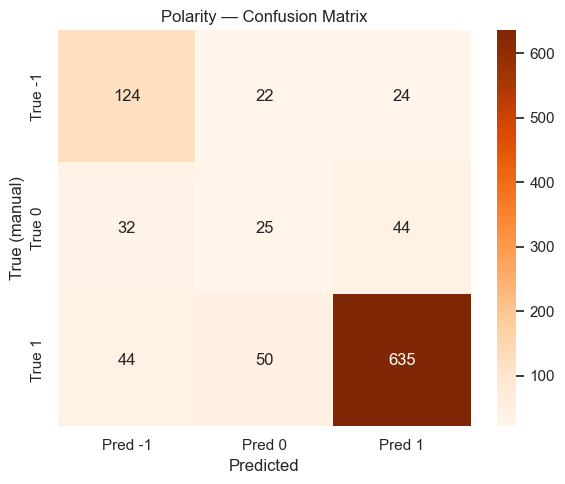

In [4]:
y_pol_true = merged_eval["manual_polarity"]
y_pol_pred = merged_eval["pred_polarity"]

pol_labels = [-1, 0, 1]
pol_names = ["Negative (-1)", "Neutral (0)", "Positive (1)"]

print("=" * 72)
print("POLARITY — classification_report (full, copy for report)")
print("=" * 72)
print(
    classification_report(
        y_pol_true,
        y_pol_pred,
        labels=pol_labels,
        target_names=pol_names,
        digits=4,
        zero_division=0,
    )
)

print("Polarity — Macro / Weighted / Micro F1")
print(
    f"  Macro F1:    {f1_score(y_pol_true, y_pol_pred, average='macro', labels=pol_labels, zero_division=0):.4f}"
)
print(
    f"  Weighted F1: {f1_score(y_pol_true, y_pol_pred, average='weighted', labels=pol_labels, zero_division=0):.4f}"
)
print(
    f"  Micro F1:    {f1_score(y_pol_true, y_pol_pred, average='micro', labels=pol_labels, zero_division=0):.4f}"
)

print("Polarity — Macro / Weighted Precision & Recall")
print(
    f"  Macro P/R:    {precision_score(y_pol_true, y_pol_pred, average='macro', labels=pol_labels, zero_division=0):.4f} / "
    f"{recall_score(y_pol_true, y_pol_pred, average='macro', labels=pol_labels, zero_division=0):.4f}"
)
print(
    f"  Weighted P/R: {precision_score(y_pol_true, y_pol_pred, average='weighted', labels=pol_labels, zero_division=0):.4f} / "
    f"{recall_score(y_pol_true, y_pol_pred, average='weighted', labels=pol_labels, zero_division=0):.4f}"
)

cm_pol = confusion_matrix(y_pol_true, y_pol_pred, labels=pol_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_pol,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Pred -1", "Pred 0", "Pred 1"],
    yticklabels=["True -1", "True 0", "True 1"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True (manual)")
ax.set_title("Polarity — Confusion Matrix")
plt.tight_layout()
plt.show()

## Notes

- **Macro** average gives equal weight to each class (good when class balance differs).
- **Weighted** average weights by support (frequency) in the gold labels.
- **Micro** for multiclass aggregates globally across all instances (shown for completeness; often tracks overall accuracy-like behavior for F1).

The printed `classification_report` already includes per-class precision, recall, and F1, plus macro/weighted/micro averages at the bottom for polarity.